___
# **MRI Inpainting Demo**
## Instructor -- Rizwan Ahmad (ahmad.46@osu.edu)
## BME5710 -- Spring 2026

This notebook demonstrates a minimal PyTorch pipeline for MRI inpainting.

**What it covers:**
1. Load training images and normalize to float32 in [0, 1]
2. Split into 225 training and 25 validation images
3. Apply a random i.i.d. Bernoulli mask (75% missing pixels) in the data loader
4. Train a single-layer CNN using MSE loss
5. Evaluate each epoch with PSNR and the competition metric: PSNR + 50×SSIM
6. Run inference on masked test images and save a Kaggle-ready submission.csv

**Network input/output:**
- Input: 2-channel tensor — channel 1 = masked image, channel 2 = binary mask (1=observed, 0=missing)
- Output: 1-channel reconstructed image (float32 in [0, 1])

**Folder structure (relative to this notebook):**
```
project/
  demo_inpainting.ipynb    ← this notebook
  train/                   ← 250 training TIFFs (train_000.tif ... train_249.tif)
  test-masked/             ← 50 masked TIFFs + 50 binary mask TIFFs
  model.pth                ← saved model weights (created by this notebook)
  submission.csv           ← Kaggle submission (created by this notebook)
```

___
### Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image                                        # for reading TIFF files
from skimage.metrics import peak_signal_noise_ratio as skpsnr  # PSNR metric
from skimage.metrics import structural_similarity as skssim    # SSIM metric

import torch
import torch.nn as nn                                        # neural network modules
from torch.utils.data import Dataset, DataLoader             # data handling utilities
import torchvision.transforms as transforms                  # for data augmentation


___
### Predefine parameters

In [ ]:
train_folder        = "train_augmented"          # folder with training TIFFs
test_masked_folder  = "test-masked"    # folder with masked test TIFFs
imag_size           = 256              # image dimensions (H = W)
mask_ratio          = 0.75             # fraction of pixels that are missing
m_total             = len([f for f in os.listdir(train_folder) if not f.startswith('.')])  # total number of images
m_tr                = int(m_total * 0.9)              # number of training images
m_val               = int(m_total * 0.1)               # number of validation images
m_te                = 50               # number of test images
batch_size          = 4                # mini-batch size
n_epochs            = 10               # number of training epochs
seed                = 0                # random seed for reproducibility

torch.manual_seed(seed)                # seed PyTorch RNG
np.random.seed(seed)                   # seed NumPy RNG

# Define data augmentations for training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),  # 50% chance to flip horizontally
    transforms.RandomVerticalFlip(p=0.5),    # 50% chance to flip vertically
    transforms.RandomRotation(degrees=180),   # Random rotation up to 180 degrees
    # Add more augmentations as needed, e.g., transforms.RandomCrop, etc.
])

# For validation, no augmentation (or minimal)
val_transform = None

DEVICE = torch.device("cpu")           # use CPU (change to "cuda" for GPU)
print(f"Using device: {DEVICE}")
if DEVICE != torch.device("cpu"):
    torch.zeros(1).cuda()

Using device: cpu


___
### Helper functions

In [5]:
# Helper function to list non-hidden files in a folder (ignoring .DS_Store and other dot-files).
def visible_files(folder):
    """Return non-hidden files in a folder (ignores .DS_Store and other dot-files)."""
    return [f for f in os.listdir(folder) if not f.startswith('.')]  # skip hidden files


# Compute the PSNR and competition metric (PSNR + 50×SSIM) for a batch of predictions and targets.
def compute_metrics(pred, target):
    """
    Compute PSNR and the competition metric (PSNR + 50×SSIM)
    averaged over a batch.
    """
    pred_np   = np.clip(pred.detach().cpu().numpy(), 0, 1)    # (B, 1, H, W), clamp to [0,1]
    target_np = np.clip(target.detach().cpu().numpy(), 0, 1) # (B, 1, H, W), clamp to [0,1]

    psnr_list   = []
    metric_list = []

    for i in range(pred_np.shape[0]):                        # loop over batch
        p = pred_np[i, 0]                                    # predicted image (H, W)
        t = target_np[i, 0]                                  # target image (H, W)

        psnr = skpsnr(t, p, data_range=1.0)                  # peak signal-to-noise ratio
        ssim = skssim(t, p, data_range=1.0)                  # structural similarity

        psnr_list.append(psnr)
        metric_list.append(psnr + 50.0 * ssim)               # competition metric

    return np.mean(psnr_list), np.mean(metric_list)

___
### Load training images

In [6]:
def load_images(folder):
    """
    Load all TIFFs from a folder.
    Returns a list of float32 numpy arrays normalized to [0, 1].
    Handles both uint8 and uint16 source images automatically.
    """
    files = sorted([                                         # collect TIFF filenames
        f for f in visible_files(folder)
        if f.lower().endswith('.tif') or f.lower().endswith('.tiff')
    ])
    assert len(files) > 0, f"No TIFF files found in {folder}"

    images = []
    for fname in files:
        with Image.open(os.path.join(folder, fname)) as im:
            img = np.array(im)
        if img.dtype == np.uint16:                         # 16-bit → divide by 65535
            img = img.astype(np.float32) / 65535.0
        elif img.dtype == np.uint8:                        # 8-bit → divide by 255
            img = img.astype(np.float32) / 255.0
        else:                                                # already float → use as-is
            img = img.astype(np.float32)
        assert img.shape == (imag_size, imag_size), (
            f"Unexpected shape {img.shape} for {fname}; expected ({imag_size}, {imag_size})"
        )
        images.append(img)

    print(f"Loaded {len(images)} images from '{folder}'")
    return images


all_images = load_images(train_folder)                       # load all 250 images
assert len(all_images) == m_tr + m_val, (
    f"Expected {m_tr + m_val} images, found {len(all_images)}"
)

train_images = all_images[:m_tr]                             # first 225 for training
val_images   = all_images[m_tr:]                             # last 25 for validation
print(f"Split: {len(train_images)} train | {len(val_images)} validation")

Loaded 2000 images from 'train_augmented'
Split: 1800 train | 200 validation


___
### Dataset and DataLoader

In [7]:
class InpaintingDataset(Dataset):
    """
    For each image, applies data augmentation (if provided), then generates a fresh 
    random i.i.d. Bernoulli mask every time the sample is accessed.

    Returns:
        masked_img : (1, H, W) float32 — full image with missing pixels zeroed out
        mask       : (1, H, W) float32 — binary mask (1=observed, 0=missing)
        full_img   : (1, H, W) float32 — ground-truth image (target)
    """
    def __init__(self, images, mask_ratio=0.75, transform=None):
        self.images     = images
        self.mask_ratio = mask_ratio
        self.transform  = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        full_img = self.images[idx]                          # (H, W) float32 in [0,1]

        # Apply data augmentation if provided
        if self.transform:
            # Convert to PIL Image for torchvision transforms
            pil_img = Image.fromarray((full_img * 255).astype(np.uint8), mode='L')
            pil_img = self.transform(pil_img)
            full_img = np.array(pil_img).astype(np.float32) / 255.0

        # i.i.d. Bernoulli mask: 1 = observed, 0 = missing
        mask = (np.random.rand(*full_img.shape) > self.mask_ratio).astype(np.float32)

        masked_img = full_img * mask                         # zero out missing pixels

        full_img   = torch.from_numpy(full_img[None])        # (H,W) → (1,H,W)
        masked_img = torch.from_numpy(masked_img[None])      # (H,W) → (1,H,W)
        mask       = torch.from_numpy(mask[None])            # (H,W) → (1,H,W)

        return masked_img, mask, full_img


train_dataset = InpaintingDataset(train_images, mask_ratio=mask_ratio, transform=train_transform)  # training set with augmentation
val_dataset   = InpaintingDataset(val_images,   mask_ratio=mask_ratio, transform=val_transform)    # validation set without augmentation

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # shuffle for training
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)  # no shuffle for validation

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 450 | Val batches: 50


___
### Built your CNN model

In [ ]:
class ThreeLayerCNN(nn.Module):
    """
    Three convolutional layers for inpainting.
    Input:  2-channel tensor (masked image + binary mask)
    Output: 1-channel reconstructed image
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=2,       # masked image + mask
            out_channels=4,     # intermediate channel size
            kernel_size=15,
            padding=7            # same padding to preserve spatial dimensions
        )
        self.conv2 = nn.Conv2d(
            in_channels=4,
            out_channels=4,
            kernel_size=15,
            padding=7
        )
        self.conv3 = nn.Conv2d(
            in_channels=4,
            out_channels=1,
            kernel_size=15,
            padding=7
        )
        self.sigmoid = nn.Sigmoid()                          # clamp output to [0, 1]


    def forward(self, masked_img, mask):
        x = torch.cat([masked_img, mask], dim=1)             # (B, 2, H, W)
        x = self.conv1(x)    # (B, 4, H, W)
        x = self.conv2(x)    # (B, 4, H, W)
        x = self.conv3(x)    # (B, 1, H, W)
        x = self.sigmoid(x)                                  # (B, 1, H, W) in [0,1]
        return x
    
class OneLayerCNN(nn.Module):
    """
    One convolutional layer for inpainting.
    Input:  2-channel tensor (masked image + binary mask)
    Output: 1-channel reconstructed image
    """
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=2,       # masked image + mask
            out_channels=1,     # intermediate channel size
            kernel_size=15,
            padding=7            # same padding to preserve spatial dimensions
        )
        self.sigmoid = nn.Sigmoid()                          # clamp output to [0, 1]

    def forward(self, masked_img, mask):
        x = torch.cat([masked_img, mask], dim=1)             # (B, 2, H, W)
        x = self.conv(x)    # (B, 1, H, W)
        x = self.sigmoid(x)                                  # (B, 1, H, W) in [0,1]
        return x

model     = OneLayerCNN().to(DEVICE)                      # instantiate and move to device
criterion = nn.MSELoss()                                     # mean squared error loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)    # Adam optimizer

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model initialized. Trainable parameters: {n_params}")

Model initialized. Trainable parameters: 451


___
### Training loop

In [35]:
print(f"{'Epoch':>5} | {'Train Loss':>12} | {'Train Metric':>14} | {'Val Loss':>10} | {'Val Metric':>12}")
print("-" * 65)

for epoch in range(1, n_epochs + 1):

    # ── Training ─────────────────────────────────────────────────────────────
    model.train()                                            # set model to training mode
    train_loss_sum   = 0.0
    train_metric_sum = 0.0
    train_n          = 0

    for masked_img, mask, full_img in train_loader:          # iterate over mini-batches
        masked_img = masked_img.to(DEVICE)
        mask       = mask.to(DEVICE)
        full_img   = full_img.to(DEVICE)

        optimizer.zero_grad()                                # reset gradients
        pred = model(masked_img, mask)                       # forward pass → (B, 1, H, W)
        loss = criterion(pred, full_img)                     # compute MSE loss
        loss.backward()                                      # backpropagation
        optimizer.step()                                     # update weights

        batch_size = full_img.shape[0]
        _, batch_metric = compute_metrics(pred, full_img)    # PSNR + 50×SSIM
        train_loss_sum   += loss.item() * batch_size
        train_metric_sum += batch_metric * batch_size
        train_n          += batch_size

    train_loss   = train_loss_sum   / train_n                # average training loss
    train_metric = train_metric_sum / train_n                # average training metric

    # ── Validation ───────────────────────────────────────────────────────────
    model.eval()                                             # set model to eval mode
    val_loss_sum   = 0.0
    val_metric_sum = 0.0
    val_n          = 0

    with torch.no_grad():                                    # disable gradient tracking
        for masked_img, mask, full_img in val_loader:
            masked_img = masked_img.to(DEVICE)
            mask       = mask.to(DEVICE)
            full_img   = full_img.to(DEVICE)

            pred = model(masked_img, mask)                   # forward pass
            loss = criterion(pred, full_img)                 # compute loss

            batch_size = full_img.shape[0]
            _, batch_metric = compute_metrics(pred, full_img)
            val_loss_sum   += loss.item() * batch_size
            val_metric_sum += batch_metric * batch_size
            val_n          += batch_size

    val_loss   = val_loss_sum   / val_n                      # average validation loss
    val_metric = val_metric_sum / val_n                      # average validation metric

    print(f"{epoch:>5} | {train_loss:>12.6f} | {train_metric:>14.4f} | {val_loss:>10.6f} | {val_metric:>12.4f}")
# print out the min/max values for the recovered images

Epoch |   Train Loss |   Train Metric |   Val Loss |   Val Metric
-----------------------------------------------------------------
    1 |     0.018073 |        33.3417 |   0.008031 |      43.2338
    2 |     0.007036 |        46.1235 |   0.006669 |      48.4707
    3 |     0.006044 |        49.5497 |   0.005916 |      50.8257
    4 |     0.005464 |        51.3984 |   0.005467 |      52.1414
    5 |     0.005131 |        52.4342 |   0.005222 |      52.8596
    6 |     0.004914 |        53.0643 |   0.005019 |      53.3913
    7 |     0.004759 |        53.4704 |   0.004868 |      53.7005
    8 |     0.004648 |        53.7278 |   0.004795 |      53.9549
    9 |     0.004554 |        53.9312 |   0.004739 |      54.1104
   10 |     0.004490 |        54.0398 |   0.004626 |      54.1940


___
### Save the model

In [36]:
torch.save(model.state_dict(), "model.pth")                  # save learned weights
print("Model saved to model.pth")

Model saved to model.pth


___
### Visualize results

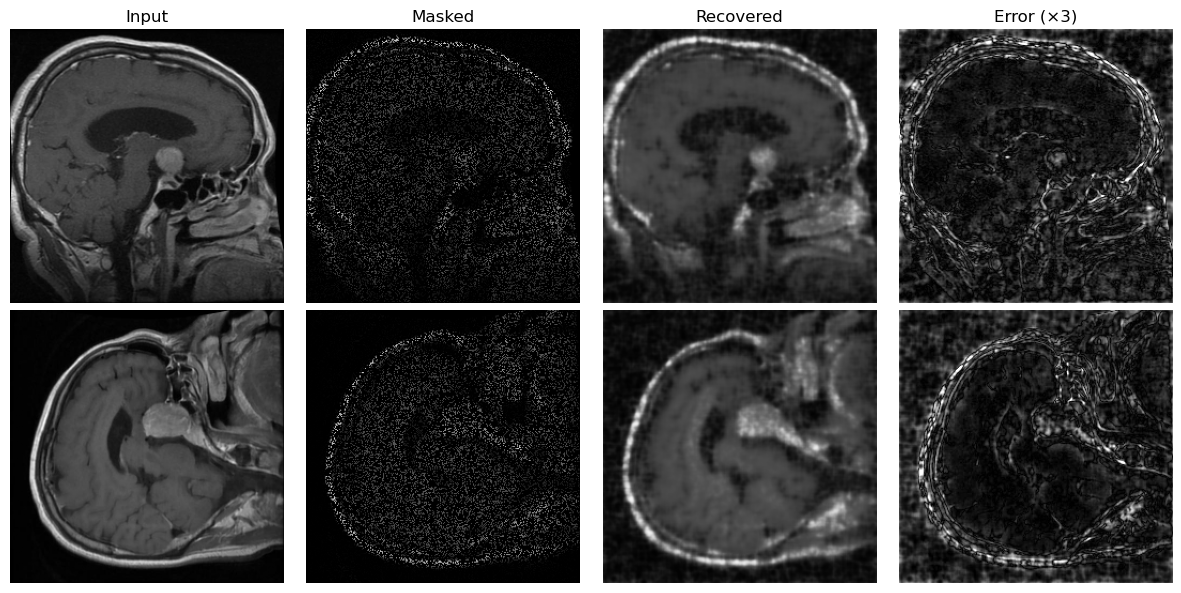

In [37]:
import random

fig, axes = plt.subplots(2, 4, figsize=(12, 6))             # 2 rows × 4 columns
model.eval()

for row, dataset in enumerate([train_dataset, val_dataset]): # row 0 = train, row 1 = val
    idx = random.randint(0, len(dataset) - 1)                # pick a random sample
    masked_img, mask, full_img = dataset[idx]                # each (1, H, W)

    with torch.no_grad():                                    # no gradients needed
        recovered = model(masked_img[None].to(DEVICE), mask[None].to(DEVICE)).cpu()

    orig   = full_img[0].numpy()                             # ground truth
    masked = masked_img[0].numpy()                           # masked input
    rec    = recovered[0, 0].numpy()                         # model output
    err    = np.abs(orig - rec) * 3                          # amplified error map

    for ax, img, title in zip(axes[row], [orig, masked, rec, err],
                               ["Input", "Masked", "Recovered", "Error (×3)"]):
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        if row == 0:
            ax.set_title(title)
        ax.axis("off")

axes[0, 0].set_ylabel("Train", fontsize=12)
axes[1, 0].set_ylabel("Val", fontsize=12)
plt.tight_layout()
plt.show()

___
### Inference on test images

Load each masked test image and its binary mask from `test-masked/`, run the trained
network, and stack the reconstructions into a single `(50, 256, 256)` float32 array
saved as `submission.csv`.

**Note:** The `_mask.tif` files were saved with pixel values 0/255. We divide by 255
when loading to recover the 0/1 float mask expected by the network.

Found 50 masked test images and 50 mask files.


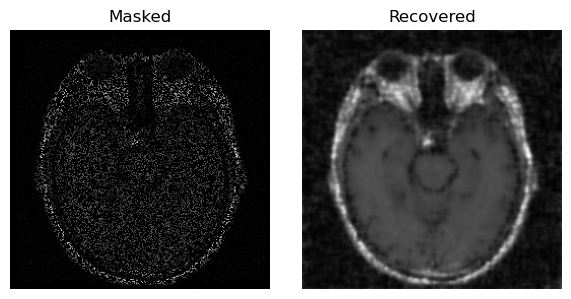

In [38]:
def load_test_sample(masked_path, mask_path):
    """
    Load a masked test image and its binary mask.
    Returns tensors ready for model input: (1, 1, H, W).
    """
    with Image.open(masked_path) as im:
        masked_img = np.array(im)
    if masked_img.dtype == np.uint16:                        # 16-bit → divide by 65535
        masked_img = masked_img.astype(np.float32) / 65535.0
    elif masked_img.dtype == np.uint8:                       # 8-bit → divide by 255
        masked_img = masked_img.astype(np.float32) / 255.0
    else:                                                    # already float → use as-is
        masked_img = masked_img.astype(np.float32)

    with Image.open(mask_path) as im:
        mask = np.array(im).astype(np.float32) / 255.0       # 0/255 uint8 → 0/1 float

    masked_img = torch.from_numpy(masked_img[None, None])    # (H,W) → (1,1,H,W)
    mask       = torch.from_numpy(mask[None, None])          # (H,W) → (1,1,H,W)

    return masked_img, mask


# Collect and sort masked images and their corresponding masks
all_test_files = sorted([
    f for f in visible_files(test_masked_folder)
    if f.lower().endswith('.tif') or f.lower().endswith('.tiff')
])

masked_files = [f for f in all_test_files if f.endswith('_masked.tif')]  # input images
mask_files   = [f for f in all_test_files if f.endswith('_mask.tif')]    # binary masks

assert len(masked_files) == m_te, f"Expected {m_te} masked images, found {len(masked_files)}"
assert len(mask_files)   == m_te, f"Expected {m_te} mask files, found {len(mask_files)}"

print(f"Found {len(masked_files)} masked test images and {len(mask_files)} mask files.")

# Run inference
model.eval()
reconstructions = []

with torch.no_grad():                                        # no gradients for inference
    for masked_fname, mask_fname in zip(masked_files, mask_files):
        masked_img, mask = load_test_sample(
            os.path.join(test_masked_folder, masked_fname),
            os.path.join(test_masked_folder, mask_fname)
        )
        masked_img = masked_img.to(DEVICE)
        mask       = mask.to(DEVICE)

        pred = model(masked_img, mask)                       # forward pass → (1,1,H,W)
        pred = pred.squeeze().cpu().numpy()                  # → (H, W)
        pred = np.clip(pred, 0.0, 1.0)                       # clamp to [0, 1]
        reconstructions.append(pred)

# Plot a random test sample
idx = random.randint(0, len(reconstructions) - 1)
test_masked = Image.open(os.path.join(test_masked_folder, masked_files[idx]))
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(np.array(test_masked).astype(np.float32), cmap="gray")
axes[0].set_title("Masked"); axes[0].axis("off")
axes[1].imshow(reconstructions[idx], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Recovered"); axes[1].axis("off")
plt.tight_layout()
plt.show()

___
### Prepare `submission.csv` to upload on Kaggle

In [39]:
# Flatten each (256, 256) reconstruction into a row of 65536 pixels
pixel_cols = [f"pixel_{j}" for j in range(imag_size * imag_size)]
rows = [rec.ravel() for rec in reconstructions]

submission_df = pd.DataFrame(rows, columns=pixel_cols, dtype=np.float32)
submission_df.insert(0, "id", [f"img_{i:03d}" for i in range(m_te)])

submission_df.to_csv("submission.csv", index=False)

print(f"Submission saved to submission.csv")
print(f"  Shape : {submission_df.shape}")
print(f"  Range : [{submission_df[pixel_cols].min().min():.4f}, {submission_df[pixel_cols].max().max():.4f}]")

Submission saved to submission.csv
  Shape : (50, 65537)
  Range : [0.0043, 0.9960]
